Penugasan Divisi Data Science & AI M5 

Evaluasi Model Machine Learning untuk Klasifikasi Sentimen Ulasan Tokopedia

Kelompok 17 <br>
Anggota:
1.   Abdulhadi Muntashir
2.   Naufal Pancar Nugraha
3.   M Hafid Ramadhan



In [2]:
# Setup dependency untuk notebook (jalankan sekali per environment/kernel)
%pip install -q scikit-learn seaborn matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Tahap 1: Data Splitting

In [4]:
# Tahap 1.1: Load dataset menggunakan Pandas
df = pd.read_csv('Datasets/tokopedia_product_reviews_2025.csv')

# Tampilkan data awal
display(df.head())

# Tahap 1.2: Isolasi kolom teks ulasan (X) dan label sentimen (y)
X = df['review_text']
y = df['sentiment_label']

# Tahap 1.3: Membagi data menjadi Training (80%) dan Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Tahap 1.4: Menampilkan dimensi (shape) dari data Training dan Testing
print("--- Dimensi Data Training ---")
print("Fitur (X_train) :", X_train.shape)
print("Target (y_train):", y_train.shape)

print("\n--- Dimensi Data Testing ---")
print("Fitur (X_test)  :", X_test.shape)
print("Target (y_test) :", y_test.shape)

,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,baru sekali ini terima brg dr belanja online d...,2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
1,cocok bgt aku sama telur nya. nga Amis menurut...,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
2,Telornya sudah sampai di rumah dengan kemasan ...,2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
3,Telor sudah diterima dengan baik dan tidak ada...,2025-07-20,1581728541,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik...",2023-04-24,881041355,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Full Design,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive


--- Dimensi Data Training ---
Fitur (X_train) : (52434,)
Target (y_train): (52434,)

--- Dimensi Data Testing ---
Fitur (X_test)  : (13109,)
Target (y_test) : (13109,)


## Interpretasi 1
Data wajib dipisahkan menjadi **training set** dan **testing set** agar performa model dapat diukur secara objektif pada data yang belum pernah dilihat sebelumnya. Training set dipakai untuk melatih model, sedangkan testing set dipakai untuk menguji apakah model mampu melakukan generalisasi ke data baru.

Risiko terbesar jika model divalidasi menggunakan data yang sama dengan data pelatihan adalah **overestimasi performa**. Model bisa terlihat sangat bagus karena hanya menghafal pola pada data training, bukan benar-benar memahami pola umum. Akibatnya, saat diterapkan pada data nyata, performanya bisa turun karena model tidak siap menghadapi data baru.

# Tahap 2: Evaluasi Model & Jebakan Metrik

In [5]:
# Tahap 2.1: Load dataset prediksi model
df_preds = pd.read_csv('Datasets/dummy_model_predictions.csv')

#Cek nama kolom di dataset prediksi
print(df_preds.columns)

y_true = df_preds['actual_sentiment']
y_pred_alpha = df_preds['pred_alpha']

# Tahap 2.2: Hitung dan tampilkan Confusion Matrix untuk Model Alpha
cm_alpha = confusion_matrix(y_true, y_pred_alpha)
print("--- Confusion Matrix: Model Alpha ---")
print(cm_alpha)
# Catatan: Baris menunjukkan label Aktual, Kolom menunjukkan label Prediksi.

# Tahap 2.3: Tampilkan metrik klasifikasi untuk Model Alpha
print("\n--- Classification Report: Model Alpha ---")
print(classification_report(y_true, y_pred_alpha))

Index(['review_id', 'actual_sentiment', 'pred_alpha', 'pred_beta',
       'pred_gamma'],
      dtype='object')
--- Confusion Matrix: Model Alpha ---
[[  31  274]
 [ 162 1533]]

--- Classification Report: Model Alpha ---
              precision    recall  f1-score   support

    negative       0.16      0.10      0.12       305
    positive       0.85      0.90      0.88      1695

    accuracy                           0.78      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.74      0.78      0.76      2000



In [6]:
# Tambahan: cek proporsi label aktual pada data testing
actual_distribution = y_true.value_counts()
actual_percentage = (actual_distribution / len(y_true) * 100).round(2)

class_balance_df = pd.DataFrame({
    'jumlah': actual_distribution,
    'persentase (%)': actual_percentage
})

print("--- Distribusi Label Aktual pada Data Testing ---")
display(class_balance_df)

--- Distribusi Label Aktual pada Data Testing ---


,jumlah,persentase (%)
actual_sentiment,,
positive,1695,84.75
negative,305,15.25


## Interpretasi 2
Jumlah ulasan aktual **tidak seimbang (imbalanced)**. Berdasarkan data testing, terdapat **1.695 ulasan positif (84,75%)** dan hanya **305 ulasan negatif (15,25%)**. Artinya, kelas positif jauh lebih dominan dibandingkan kelas negatif.

Dalam kondisi seperti ini, metrik **accuracy** bisa menipu. Misalnya, model yang selalu menebak semua ulasan sebagai positif tetap dapat menghasilkan akurasi tinggi karena sebagian besar data memang positif. Padahal, model seperti itu gagal menjalankan fungsi bisnis utama, yaitu mendeteksi komplain atau ulasan negatif. Karena itu, evaluasi harus melihat **precision, recall, dan F1-score**, terutama untuk kelas negatif.

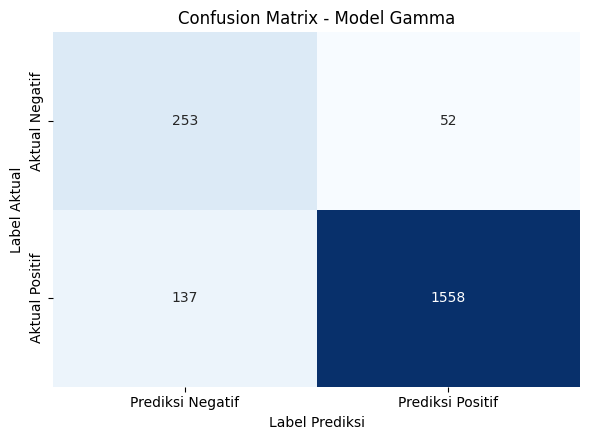

In [10]:
# Visualisasi tambahan: Confusion Matrix Model Gamma
y_pred_gamma = df_preds['pred_gamma']
cm_gamma = confusion_matrix(y_true, y_pred_gamma)

plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm_gamma,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Prediksi Negatif', 'Prediksi Positif'],
    yticklabels=['Aktual Negatif', 'Aktual Positif']
 )
plt.title('Confusion Matrix - Model Gamma')
plt.xlabel('Label Prediksi')
plt.ylabel('Label Aktual')
plt.tight_layout()
plt.show()

## Interpretasi 3
Berdasarkan **Confusion Matrix Model Gamma** `[[253, 52], [137, 1558]]` (baris = label aktual, kolom = label prediksi), model berhasil menangkap **253 komplain** dengan benar dan masih melewatkan **52 komplain** (aktual negatif tetapi diprediksi positif). Jika kelas positif didefinisikan sebagai ulasan positif, maka 52 kasus ini termasuk **false positive** terhadap kelas positif, dan secara ekuivalen merupakan **false negative pada kelas komplain (negatif)**. Ini berarti kebocoran komplain sudah jauh lebih kecil dibanding Model Alpha.

Secara metrik, **Recall Negatif Model Gamma = 0,83** karena model menangkap `253 dari 305` total komplain (sekitar **83%**). Bagi bisnis, ini sangat krusial karena semakin tinggi recall negatif, semakin kecil risiko pelanggan yang kecewa terabaikan.

Di sisi lain, ada **137 ulasan positif** yang diprediksi sebagai negatif (false alarm). Konsekuensinya, tim operasional mungkin meninjau beberapa kasus yang sebenarnya tidak bermasalah, tetapi trade-off ini umumnya masih lebih aman dibanding kehilangan komplain pelanggan yang nyata.

# Tahap 3: Diagnosis Kesehatan Model

In [7]:
y_pred_beta = df_preds['pred_beta']
y_pred_gamma = df_preds['pred_gamma']

# Tahap 3.1: Tampilkan classification_report untuk Model Beta
print("--- Classification Report: Model Beta ---")
print(classification_report(y_true, y_pred_beta))

# Tahap 3.2: Tampilkan classification_report untuk Model Gamma
print("\n--- Classification Report: Model Gamma ---")
print(classification_report(y_true, y_pred_gamma))

--- Classification Report: Model Beta ---
              precision    recall  f1-score   support

    negative       0.16      0.46      0.23       305
    positive       0.85      0.55      0.67      1695

    accuracy                           0.54      2000
   macro avg       0.50      0.51      0.45      2000
weighted avg       0.75      0.54      0.61      2000


--- Classification Report: Model Gamma ---
              precision    recall  f1-score   support

    negative       0.65      0.83      0.73       305
    positive       0.97      0.92      0.94      1695

    accuracy                           0.91      2000
   macro avg       0.81      0.87      0.84      2000
weighted avg       0.92      0.91      0.91      2000



In [9]:
# Tambahan: ringkasan perbandingan akurasi training vs testing dan recall negatif
summary_df = pd.DataFrame({
    'model': ['Alpha', 'Beta', 'Gamma'],
    'training_accuracy': [0.99, 0.55, 0.92],
    'testing_accuracy': [
        round(accuracy_score(y_true, y_pred_alpha), 2),
        round(accuracy_score(y_true, y_pred_beta), 2),
        round(accuracy_score(y_true, y_pred_gamma), 2)
    ],
    'negative_recall': [0.10, 0.46, 0.83]
})

summary_df['gap_train_test'] = (summary_df['training_accuracy'] - summary_df['testing_accuracy']).round(2)
summary_df

,model,training_accuracy,testing_accuracy,negative_recall,gap_train_test
0,Alpha,0.99,0.78,0.10,0.21
1,Beta,0.55,0.54,0.46,0.01
2,Gamma,0.92,0.91,0.83,0.01


# Tahap 4: Kesimpulan Akhir

## Interpretasi 4
Jika dibandingkan antara **training accuracy** dan **testing accuracy**, maka diagnosis kesehatan model adalah sebagai berikut.

**Model Alpha** mengalami **overfitting**. Training accuracy-nya sangat tinggi, yaitu **99%**, tetapi testing accuracy hanya sekitar **78%**. Selisih yang besar ini menunjukkan model terlalu menyesuaikan diri dengan data training dan tidak cukup baik dalam melakukan generalisasi pada data baru. Selain itu, recall kelas negatifnya juga sangat rendah.

**Model Beta** mengalami **underfitting**. Training accuracy **55%** dan testing accuracy sekitar **54%**, yang sama-sama rendah. Ini menandakan model belum berhasil mempelajari pola penting dari data, baik pada training maupun testing.

**Model Gamma** merupakan **good fit / ideal fit**. Training accuracy **92%** dan testing accuracy sekitar **91%**, dengan selisih yang sangat kecil. Hal ini menunjukkan model cukup baik mempelajari pola pada data training dan tetap mampu mempertahankan performa pada data testing. Selain itu, recall kelas negatif Model Gamma juga paling tinggi, yaitu **0,83**.

## Interpretasi 5: Kesimpulan Akhir
Model yang **paling layak di-deploy ke tahap produksi adalah Model Gamma**. Selain performa umum yang kuat, Confusion Matrix Gamma menunjukkan kemampuan deteksi komplain yang paling baik: dari **305 komplain aktual**, model berhasil menangkap **253** dan hanya melewatkan **52** komplain.

Jika dibandingkan dengan Model Alpha yang melewatkan **274 komplain**, maka Gamma menurunkan kebocoran komplain secara drastis. Ini membuat risiko pengabaian pelanggan jauh lebih kecil dan lebih selaras dengan kebutuhan bisnis yang menekankan respons cepat terhadap keluhan.

Dari sisi kesehatan model, Gamma juga termasuk **good fit** karena selisih training accuracy (**92%**) dan testing accuracy (**91%**) sangat kecil. Dengan demikian, untuk kebutuhan bisnis yang menekankan deteksi komplain agar tidak terabaikan, **Model Gamma tetap menjadi pilihan terbaik**.